In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 as cv2

In [10]:
train_df = pd.read_csv(r'D:\SurfaceGuard_AI\data\train.csv')
print(f"Total no of rows:{train_df.shape[0]}")
print(f"Total no of columns:{train_df.shape[1]}")

Total no of rows:45572
Total no of columns:5


In [66]:
train_df.head(20)

,image_id,defect_type,mask_rle,width,height
0,4S22I7SA34,defect_a,7255 6 7377 12 7505 12 7633 12 7762 11 7890 11...,800,128
1,4S22I7SA34,defect_b,NaN,800,128
2,4S22I7SA34,defect_c,NaN,800,128
3,4S22I7SA34,defect_d,NaN,800,128
4,DZ899111OE,defect_a,NaN,800,128
5,DZ899111OE,defect_b,NaN,800,128
6,DZ899111OE,defect_c,NaN,800,128
7,DZ899111OE,defect_d,NaN,800,128
8,GVDJ3PQ5QT,defect_a,NaN,800,128
9,GVDJ3PQ5QT,defect_b,NaN,800,128


In [13]:
print(f"Total no of unique image_id's: {len(train_df['image_id'].unique())}")

Total no of unique image_id's: 11393


In [11]:
print(f"Total no of unique defect type: {len(train_df['defect_type'].unique())}")

Total no of unique defect type: 4


In [12]:
train_df['defect_type'].value_counts()

defect_type
defect_a    11393
defect_b    11393
defect_c    11393
defect_d    11393
Name: count, dtype: int64

From the above observation I noticed that train dataset contains each row for each image with all the four defects and has mask_rle for specific defect and others are null. So I couldn't conclude the class balances need to look the presence of mask_rle to get class distribution

In [15]:
train_df.loc[train_df['mask_rle'].isna(),'defect_type'].value_counts()

defect_type
defect_b    11080
defect_a    10312
defect_d     9686
defect_c     7293
Name: count, dtype: int64

In [21]:
print(f"True defect count:\n{train_df.loc[train_df['mask_rle'].notna(),'defect_type'].value_counts()}")


True defect count:
defect_type
defect_c    4100
defect_d    1707
defect_a    1081
defect_b     313
Name: count, dtype: int64


In [22]:
nan_counts = train_df.loc[train_df['mask_rle'].isna(),'image_id'].value_counts()

zero_defect_images = (nan_counts==4).sum()
print(f"Zero defect image count: {zero_defect_images}")

Zero defect image count: 5516


## RLE to Mask conversion logic

In [58]:
from numpy import dtype
def rle_to_mask(rle_string,height,width):
    if pd.isna(rle_string) or rle_string == "":
        return np.zeros((height,width),dtype=np.uint8)
    rle_int=[int(x) for x in rle_string.split()] 
    mask_1d = np.zeros((height*width),dtype=np.uint8)
    for i in range(0,len(rle_int),2):
        start_pixel = rle_int[i] - 1
        length = rle_int[i+1]
        #print(start_pixel,length)
        mask_1d[start_pixel:start_pixel+length] = 1
    mask_2d = mask_1d.reshape((height,width),order='F')
    return mask_2d


In [41]:
train_df[:][:1]

,image_id,defect_type,mask_rle,width,height
0,4S22I7SA34,defect_a,7255 6 7377 12 7505 12 7633 12 7762 11 7890 11...,800,128


In [49]:
rle_string = train_df.loc[0,'mask_rle']
height = train_df.loc[0,'height']
width = train_df.loc[0,'width']
height,width,rle_string

(np.int64(128),
 np.int64(800),
 '7255 6 7377 12 7505 12 7633 12 7762 11 7890 11 8018 11 8146 11 19503 28 19631 32 19759 36 19886 41 20014 45 20142 49 20269 53 20397 52 20525 52 20654 13 20673 32 20785 8 20807 25 20915 4 20941 19 21075 13 21211 4 21362 15 21476 29 21604 29 21732 29 21859 30 21987 30 22115 30 22242 27 22370 16 22434 14 22497 15 22561 19 22625 7 22689 19 22753 1 22817 19 22945 19 23073 19 23201 19 23328 20 23461 15 47408 4 47526 14 47654 14 47782 14 47910 14 48038 14 48166 11 48294 2')

In [59]:
rle_to_mask(rle_string=rle_string,height=height,width=width)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(128, 800), dtype=uint8)

## CV2 Visualization

In [61]:
from matplotlib.pyplot import contour
def visualize_mask_open_cv(image_path,mask_2d,alpha=0.4,color=(0,255,0)):
    """
    Overlays a 2D binary mask onto an image using OpenCV.
    
    Parameters:
    - image_path: Path to the raw image file.
    - mask_2d: The 2D numpy binary array (0s and 1s) from rle_to_mask.
    - alpha: Opacity of the mask overlay (0.0 = invisible, 1.0 = solid color).
    - color: BGR color tuple for the defect. (0, 255, 0) is Green.
    """
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Could not load image at {image_path}")
    colored_mask = np.zeros_like(image)
    colored_mask[mask_2d==1]=color
    
    overlay = cv2.addWeighted(image,1.0,colored_mask,alpha,0)
    contours,_ = cv2.findContours(mask_2d,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay,contours,-1,color,thickness=2)
    return overlay

### Defect A

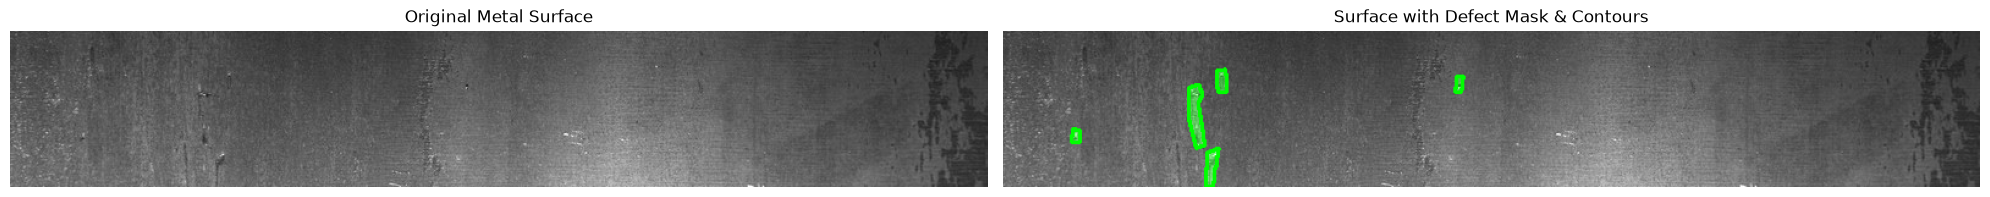

In [65]:
image_path=r"D:\SurfaceGuard_AI\data\train\4S22I7SA34.jpg"
overlay_bgr = visualize_mask_open_cv(image_path=image_path,mask_2d=rle_to_mask(rle_string=rle_string,height=height,width=width))
original_bgr = cv2.imread(image_path)

fig, axes = plt.subplots(1, 2, figsize=(20,8))

# Plot 1: Original Image
# Need to convert BGR to RGB for matplotlib!
original_rgb = cv2.cvtColor(original_bgr,cv2.COLOR_BGR2RGB)
axes[0].imshow(original_rgb)
axes[0].set_title("Original Metal Surface")
axes[0].axis('off')

# Plot 2: Your Custom Overlay
overlay_rgb = cv2.cvtColor(overlay_bgr,cv2.COLOR_BGR2RGB)
axes[1].imshow(overlay_rgb)
axes[1].set_title("Surface with Defect Mask & Contours")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [78]:
train_df.head(60)
defect_a_sample = train_df.loc[0]
defect_b_sample = train_df.loc[45]
defect_c_sample = train_df.loc[18]
defect_d_sample = train_df.loc[23]
print(f"defect_a_sample:{pd.DataFrame(defect_a_sample)}")
print(f"defect_b_sample:{pd.DataFrame(defect_b_sample)}")
print(f"defect_c_sample:{pd.DataFrame(defect_c_sample)}")
print(f"defect_d_sample:{pd.DataFrame(defect_d_sample)}")

defect_a_sample:                                                             0
image_id                                            4S22I7SA34
defect_type                                           defect_a
mask_rle     7255 6 7377 12 7505 12 7633 12 7762 11 7890 11...
width                                                      800
height                                                     128
defect_b_sample:                                                            45
image_id                                            JBAI4VEGD5
defect_type                                           defect_b
mask_rle     36471 10 36585 24 36700 37 36818 47 36946 47 3...
width                                                      800
height                                                     128
defect_c_sample:                                                            18
image_id                                            30WEUKWBQT
defect_type                                           defect_c
mask_rl

### Defect C

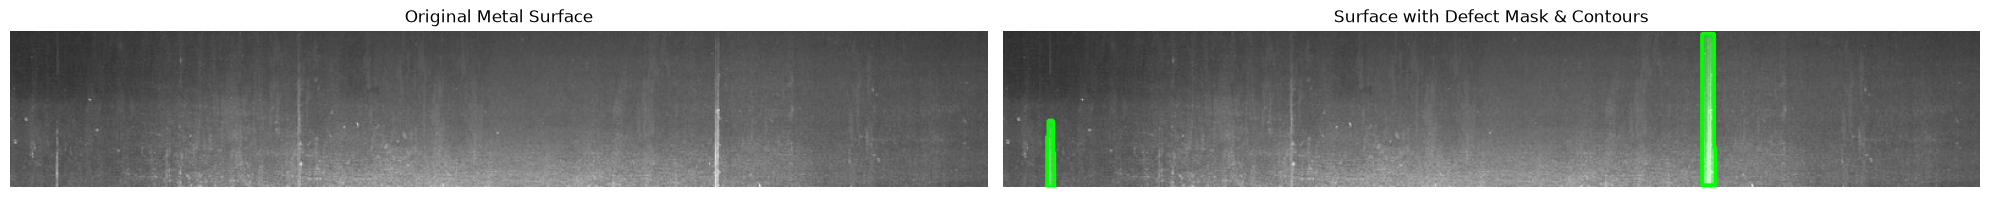

In [71]:
image_path=r"D:\SurfaceGuard_AI\data\train\30WEUKWBQT.jpg"
rle_string=train_df.loc[18,'mask_rle']
height=train_df.loc[18,'height']
width=train_df.loc[18,'width']
overlay_bgr = visualize_mask_open_cv(image_path=image_path,mask_2d=rle_to_mask(rle_string=rle_string,height=height,width=width))
original_bgr = cv2.imread(image_path)

fig, axes = plt.subplots(1, 2, figsize=(20,8))

# Plot 1: Original Image
# Need to convert BGR to RGB for matplotlib!
original_rgb = cv2.cvtColor(original_bgr,cv2.COLOR_BGR2RGB)
axes[0].imshow(original_rgb)
axes[0].set_title("Original Metal Surface")
axes[0].axis('off')

# Plot 2: Your Custom Overlay
overlay_rgb = cv2.cvtColor(overlay_bgr,cv2.COLOR_BGR2RGB)
axes[1].imshow(overlay_rgb)
axes[1].set_title("Surface with Defect Mask & Contours")
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Defect d

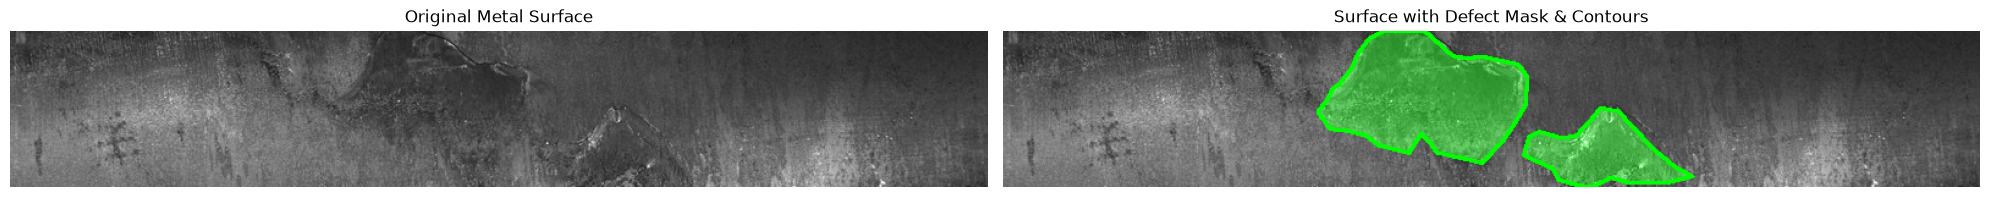

In [72]:
image_path=r"D:\SurfaceGuard_AI\data\train\6MBBS0WBUK.jpg"
rle_string=train_df.loc[23,'mask_rle']
height=train_df.loc[23,'height']
width=train_df.loc[23,'width']
overlay_bgr = visualize_mask_open_cv(image_path=image_path,mask_2d=rle_to_mask(rle_string=rle_string,height=height,width=width))
original_bgr = cv2.imread(image_path)

fig, axes = plt.subplots(1, 2, figsize=(20,8))

# Plot 1: Original Image
# Need to convert BGR to RGB for matplotlib!
original_rgb = cv2.cvtColor(original_bgr,cv2.COLOR_BGR2RGB)
axes[0].imshow(original_rgb)
axes[0].set_title("Original Metal Surface")
axes[0].axis('off')

# Plot 2: Your Custom Overlay
overlay_rgb = cv2.cvtColor(overlay_bgr,cv2.COLOR_BGR2RGB)
axes[1].imshow(overlay_rgb)
axes[1].set_title("Surface with Defect Mask & Contours")
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Defect B

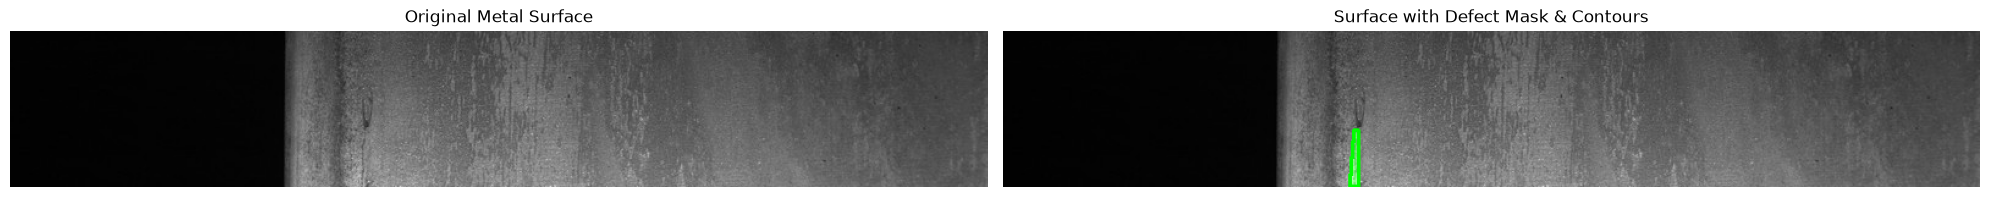

In [75]:
image_path=r"D:\SurfaceGuard_AI\data\train\JBAI4VEGD5.jpg"
rle_string=train_df.loc[45,'mask_rle']
height=train_df.loc[45,'height']
width=train_df.loc[45,'width']
overlay_bgr = visualize_mask_open_cv(image_path=image_path,mask_2d=rle_to_mask(rle_string=rle_string,height=height,width=width))
original_bgr = cv2.imread(image_path)

fig, axes = plt.subplots(1, 2, figsize=(20,8))

# Plot 1: Original Image
# Need to convert BGR to RGB for matplotlib!
original_rgb = cv2.cvtColor(original_bgr,cv2.COLOR_BGR2RGB)
axes[0].imshow(original_rgb)
axes[0].set_title("Original Metal Surface")
axes[0].axis('off')

# Plot 2: Your Custom Overlay
overlay_rgb = cv2.cvtColor(overlay_bgr,cv2.COLOR_BGR2RGB)
axes[1].imshow(overlay_rgb)
axes[1].set_title("Surface with Defect Mask & Contours")
axes[1].axis('off')

plt.tight_layout()
plt.show()